In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 2: Install required libraries
!pip install holidays xgboost --quiet

In [3]:
# Step 3: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [4]:
# Visuals
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [6]:
# Step 4: Load your dataset from Drive
file_path = '/content/drive/MyDrive/Datasets/AEP_hourly/AEP_hourly.csv'
df = pd.read_csv(file_path)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

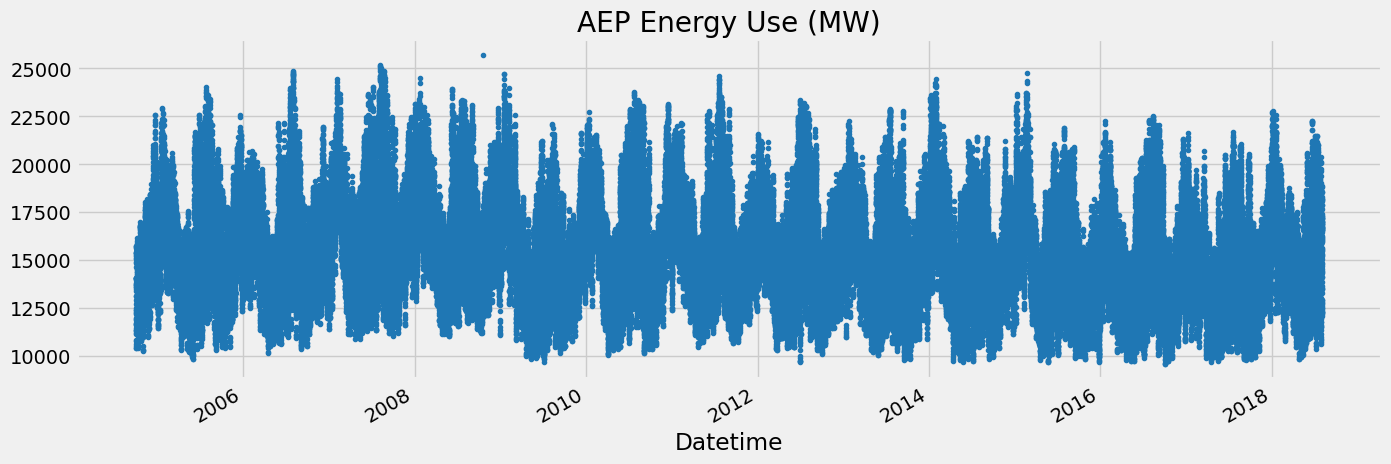

In [7]:
# Step 5: Initial plot
df['AEP_MW'].plot(style='.', figsize=(15, 5), color=color_pal[0], title='AEP Energy Use (MW)')
plt.show()

In [8]:
# Step 6: Split data
train = df.loc[df.index < '2015-01-01']
test = df.loc[df.index >= '2015-01-01']

In [20]:
# Step 7: Feature creation
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = df['dayofweek'] >= 5
    # US holidays
    us_holidays = holidays.US()
    df['is_holiday'] = df.index.to_series().apply(lambda x: 1 if x in us_holidays else 0)
    # Lag features
    df['lag1'] = df['AEP_MW'].shift(1)
    df['lag24'] = df['AEP_MW'].shift(24)
    df['rolling_mean_24'] = df['AEP_MW'].shift(1).rolling(window=24).mean()
    df['rolling_std_24'] = df['AEP_MW'].shift(1).rolling(window=24).std()
    return df

In [21]:
# Step 8: Apply feature engineering
train = create_features(train).dropna()
test = create_features(test).dropna()

In [22]:
# Step 9: Define features and target
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
            'dayofmonth', 'weekofyear', 'is_weekend', 'is_holiday',
            'lag1', 'lag24', 'rolling_mean_24', 'rolling_std_24']
TARGET = 'AEP_MW'

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

In [23]:
# Step 10: Train XGBoost model
reg = xgb.XGBRegressor(
    n_estimators=500,
    early_stopping_rounds=25,
    objective='reg:squarederror',
    max_depth=6,
    learning_rate=0.05,
    verbosity=1
)

reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:2450.18740	validation_1-rmse:2557.16505
[100]	validation_0-rmse:296.01985	validation_1-rmse:322.03021
[200]	validation_0-rmse:248.96269	validation_1-rmse:280.74448
[300]	validation_0-rmse:228.39606	validation_1-rmse:267.62916
[400]	validation_0-rmse:217.11862	validation_1-rmse:262.66455
[499]	validation_0-rmse:208.75686	validation_1-rmse:259.14103


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=25,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [24]:
# Step 11: Predictions
test['prediction'] = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, test['prediction']))
print(f'✅ RMSE Score: {rmse:.2f}')

✅ RMSE Score: 259.14


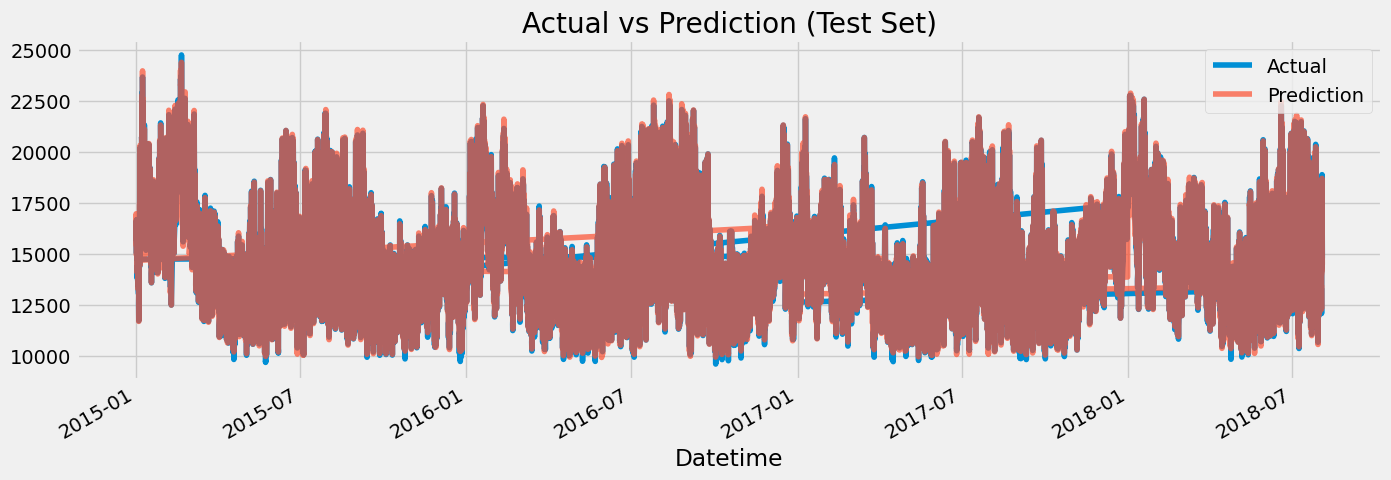

In [25]:
# Step 12: Plot results
fig, ax = plt.subplots(figsize=(15, 5))
test['AEP_MW'].plot(ax=ax, label='Actual')
test['prediction'].plot(ax=ax, label='Prediction', alpha=0.7)
ax.set_title('Actual vs Prediction (Test Set)')
plt.legend()
plt.show()

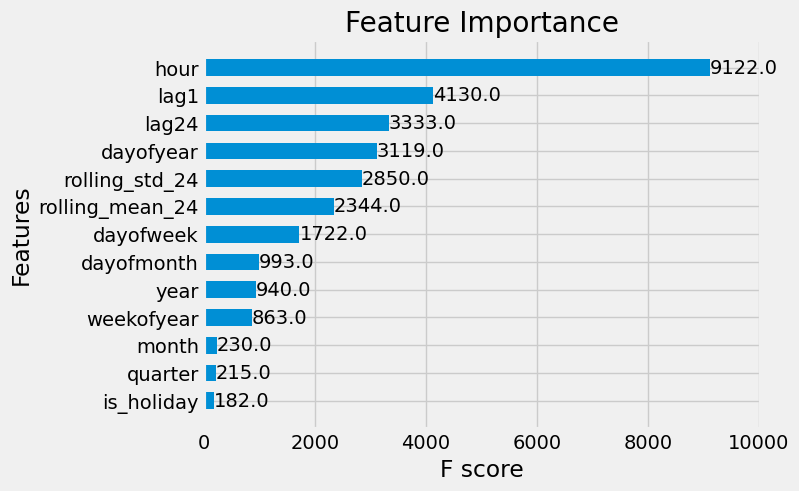

In [26]:
# Step 13: Feature importance
xgb.plot_importance(reg, height=0.6)
plt.title("Feature Importance")
plt.show()